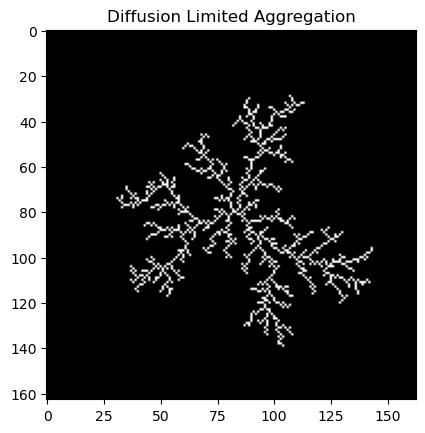

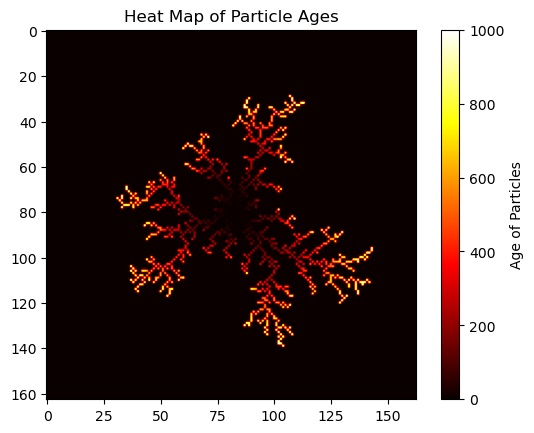

In [2]:
# RUNLOG:

# After kill radius
# 14.2 s for N=1000
# 3 min 32 s for N = 5000
#
#
# After random.getrandbits(2)
# 7.3 s for N=1000
#
#
#
#

import numpy as np
import matplotlib.pyplot as plt
import random

radius = 21
length = 52


heat = np.zeros((length, length))                         # tracks age of particles


                                                          # v changed 100 to 101 so the seed is actually centered
space = np.zeros((length, length), dtype=bool)            # boolean array to represent discrete 2D space (102x102 blocks): True for occupied block, false for empty block
space[length//2, length//2] = True                        # puts the seed in the middle


stickiness = 1                                            # factor value between (0 to 1). The chance it has of sticking to the seed

seed = True


def spawn(radius):
    theta = np.random.uniform(0, 2 * np.pi)                                                                 # generates a random angle between 0 and 2pi
    x, y = int(radius * np.cos(theta)), int(radius * np.sin(theta))
    return x, y


def find_rmax(i, x, y):
    global length, space, heat, radius, r_max                      # I should probably pass these later but rn Im just testing stuff
    
    r_i = int(np.sqrt((x - length//2)**2 + (y - length//2)**2)) + 1               # distance from the center seed

    if i == 0:
        r_max = 1

    elif r_i > r_max:
        r_max = r_i

    return r_max

def resizing_circle(i, x, y):                                                  # spawn points         
    ##############################################
    # Adaptive resizing
    global length, space, heat, radius                                         # I should probably pass these later but rn Im just testing stuff
    
    r_max = find_rmax(i, x, y)

    if radius < r_max + 10:
        new_radius = r_max + 10
        x, y = spawn(new_radius)    
        radius = new_radius   

def resizing_square(i, x, y):                                                  # boundaries
    ##############################################
    # Adaptive resizing
    global length, space, heat                                          # I should probably pass these later but rn Im just testing stuff
    
    r_max =find_rmax(i, x, y)
    if length < (2 * r_max) + 20:                                              # condition to adjust length
        new_length = length + 10
        if new_length % 2 == 0:                                         # ensures new length is odd so seed can remain centered
            new_length += 1

        new_space = np.zeros((new_length, new_length), dtype=bool)      # adjusts space to new length dimensions
        new_heat = np.zeros((new_length, new_length))                   # adjusts heat to new length dimensions

        shift = (new_length - length) // 2                              # shift such that the space expands outwards from center

        crystal_indices = np.argwhere(space)                            # ^ adjusts space such that it adds space outwards from center
        for x, y in crystal_indices:
            new_space[x + shift, y + shift] = True
            new_heat[x + shift, y + shift] = heat[x, y]
        
        length = new_length                                             # updates length
        space = new_space                                               # updates space
        heat = new_heat                                                 # updates heat

    ##############################################

def kill(i, x, y):
    global length, space, heat, radius                                              # I should probably pass these later but rn Im just testing stuff

    r_i = int(np.sqrt((x - length//2)**2 + (y - length//2)**2)) + 1               # distance from the center seed

    if r_i > radius + 10:
        return True
    else:
        return False


def random_walk(i):
    global length, space, heat, radius                                              # I should probably pass these later but rn Im just testing stuff


    x, y = spawn(radius)                                                            # spawns particle at random point on circle
    x += length // 2                                                                # aligns circle to be centered at the seed
    y += length // 2                                                                # aligns circle to be centered at the seed  


    while (True):                           # Loop until the particle sticks to seed
        # RANDOM WALK ALGORITHM
        direction = random.getrandbits(2)

        # particles bounce off walls instead of periodic BC but its effectively the same.
        if direction == 0:        
            y += 1
        elif direction == 1:
            y -= 1
        elif direction == 2:
            x -= 1
        else:
            x += 1
        
        if kill(i, x, y):                                                          # checks if particle is too far from the seed and kills it if it is
            x, y = spawn(radius)                                                    # respawns particle at random point on circle
            x += length // 2                                                            # aligns circle to be centered at the seed
            y += length // 2                                                            # aligns circle to be centered at the seed
            continue                                                     

        # Check if particle is next to the seed (3x3 neighborhood)
                                                                                # checks 3x3 neighborhood for crystal
        if 0 < x < length - 1 and 0 < y < length - 1:                           # only checks if particle is not on the edge to avoid errors (aggregate does not approach edge so this is fine)
            if (space[x-1, y-1] or space[x-1, y] or space[x-1, y+1] or          # checks 3x3 neighborhood for crystal
                space[x,   y-1]                  or space[x,   y+1] or
                space[x+1, y-1] or space[x+1, y] or space[x+1, y+1]
                and not space[x, y]):                                            # ensures spot is not already occupied 

                if np.random.rand() < stickiness:                               # Chance of sticking to the seed is the stickiness factor
                    space[x, y] = seed
                    heat[x, y] = i + 1                                          # tracks the age of the particle that sticks to the seed
                    resizing_square(i, x, y)
                    resizing_circle(i, x, y)
                    break                                                       # moved break inside the if so it only breaks if the particle sticks


# DLA Simulation

x, y = spawn(radius)


N = 1000 # number of particles
for i in range(N):
    random_walk(i)

# image plotting from matplotlib plots the space array
plt.imshow(space, cmap='gray')
plt.title('Diffusion Limited Aggregation')
plt.show()

# plot heat map
plt.imshow(heat, cmap='hot')
plt.title('Heat Map of Particle Ages')
plt.colorbar(label='Age of Particles')
plt.show()

In [4]:
np.shape?


Signature:       np.shape(a)
Call signature:  np.shape(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function shape at 0x0000029BD998A1F0>
File:            c:\users\16152\anaconda3\envs\myenv\lib\site-packages\numpy\core\fromnumeric.py
Docstring:      
Return the shape of an array.

Parameters
----------
a : array_like
    Input array.

Returns
-------
shape : tuple of ints
    The elements of the shape tuple give the lengths of the
    corresponding array dimensions.

See Also
--------
len : ``len(a)`` is equivalent to ``np.shape(a)[0]`` for N-D arrays with
      ``N>=1``.
ndarray.shape : Equivalent array method.

Examples
--------
>>> np.shape(np.eye(3))
(3, 3)
>>> np.shape([[1, 3]])
(1, 2)
>>> np.shape([0])
(1,)
>>> np.shape(0)
()

>>> a = np.array([(1, 2), (3, 4), (5, 6)],
...              dtype=[('x', 'i4'), ('y', 'i4')])
>>> np.shape(a)
(3,)
>>> a.shape
(3,)
Class docstring:
Class to wrap functions with checks for __array_function__ overrides.

All 

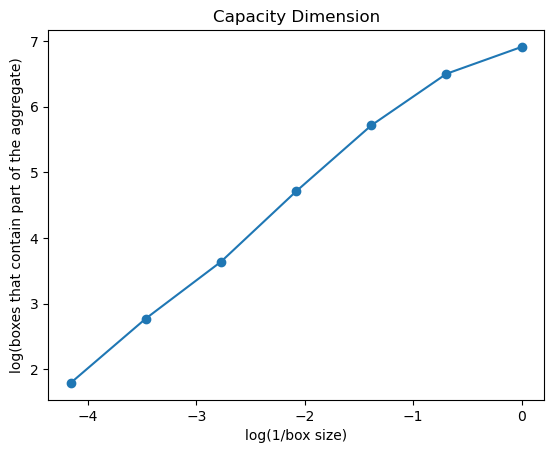

In [10]:
# Capacity Dimension Calculation

def box_partitioning(space, delta_length):
    length = space.shape[0]                     # same as len but for higher dimension arrays
    count = 0
    for i in range(0, length, delta_length):        # delta length = box size
        for j in range(0, length, delta_length):
            if np.any(space[i:i+delta_length, j:j+delta_length]):   # checks the slice of space from the edge of box the the next edge if there are any "true" or 1s in it
                count += 1
    return count

delta_lengths = [1, 2, 4, 8, 16, 32, 64]
counts = [box_partitioning(space, size) for size in delta_lengths]
log_counts = np.log(counts)
log_sizes = np.log(1/np.array(delta_lengths))
plt.plot(log_sizes, log_counts, marker='o')
plt.title('Capacity Dimension')
plt.xlabel('log(1/box size)')
plt.ylabel('log(boxes that contain part of the aggregate)')
plt.show()


In [6]:
np.polyfit?
           

Signature:       np.polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)
Call signature:  np.polyfit(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function polyfit at 0x0000029BD9B14A60>
File:            c:\users\16152\anaconda3\envs\myenv\lib\site-packages\numpy\lib\polynomial.py
Docstring:      
Least squares polynomial fit.

.. note::
   This forms part of the old polynomial API. Since version 1.4, the
   new polynomial API defined in `numpy.polynomial` is preferred.
   A summary of the differences can be found in the
   :doc:`transition guide </reference/routines.polynomials>`.

Fit a polynomial ``p(x) = p[0] * x**deg + ... + p[deg]`` of degree `deg`
to points `(x, y)`. Returns a vector of coefficients `p` that minimises
the squared error in the order `deg`, `deg-1`, ... `0`.

The `Polynomial.fit <numpy.polynomial.polynomial.Polynomial.fit>` class
method is recommended for new code as it is more stable numerically. See
the documentation of th

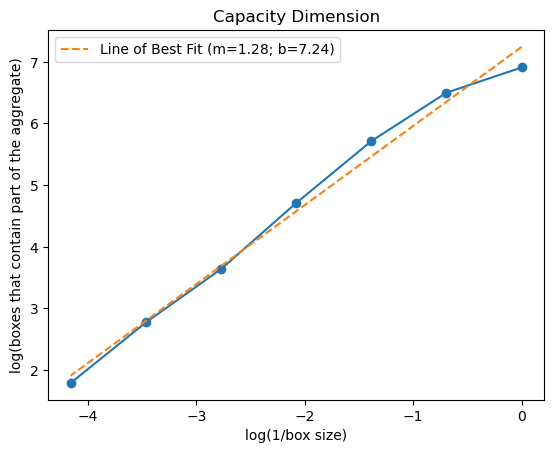

In [11]:
fit=np.polyfit(log_sizes, log_counts, 1)  
capacity_dimension = fit[0]        
b = fit[1]

overlay = capacity_dimension * log_sizes + b

plt.plot(log_sizes, log_counts, marker='o')
plt.plot(log_sizes, overlay, '--' ,label=f'Line of Best Fit (m={capacity_dimension:.2f}; b={b:.2f})') # dashed line?
plt.title('Capacity Dimension')
plt.xlabel('log(1/box size)')
plt.ylabel('log(boxes that contain part of the aggregate)')
plt.legend()
plt.show()